<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/gn_model_capacity_simulation_experiment_validation_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# GN 모델 교차검증: 독립 시뮬레이션 논문 + 7종 광섬유 전송 실험

목적은 사용자 closed-form GN 코드가 (1) 다른 연구자의 GN 기반 capacity 곡선과 유사한 결과를 내는지, (2) 실제 광섬유 실험의 optimum launch power와 고정 용량 도달거리를 추정할 수 있는지 분리해 검증하는 것입니다.

## 두 벤치마크의 성격

1. **GN 시뮬레이션 논문:** Sohanpal *et al.* Fig. 2 HCF. 29×140 GBd DP 채널의 Shannon throughput 대 launch power. 첫 번째 노트북에서 RMSE/MAPE를 계산했습니다.
2. **실험 논문:** Nespola *et al.*, *GN-Model Validation over Seven Fiber Types in Uncompensated PM-16QAM Nyquist-WDM Links*. 22×125 Gb/s(총 2.75 Tb/s)의 실제 전송에서 BER=1.5×10⁻²를 만족하는 최대 reach 대 launch power를 측정했습니다.

두 번째 벤치마크의 capacity는 Shannon 연속값이 아니라 **PM-16QAM으로 고정된 2.75 Tb/s gross capacity를 얼마나 멀리 보낼 수 있는가**입니다. 실험 Fig. 4의 WDM B2B 곡선에서 목표 BER의 equivalent threshold를 읽어 단말기 구현 손실을 정렬했으며, 광섬유별 NLI 계수는 피팅하지 않았습니다.

In [1]:
import numpy, scipy, matplotlib, pandas
print('Dependencies: OK')


Dependencies: OK


=== Nespola et al. experimental fixed-capacity benchmark ===
Gross line rate = 22 x 125 Gb/s = 2.75 Tb/s; target BER = 1.5e-2
Digitized terminal threshold used for convention alignment: 17.7 dB
  Fiber  Experiment Lmax km  Model Lmax km  Reach error %  Experiment Popt dBm  Model Popt dBm  Popt error dB
   SSMF                1940       1889.220         -2.618               -7.500          -7.500          0.000
  NZDSF                 602        551.980         -8.309              -10.000         -10.550         -0.550
 PSCF80                2395       2340.920         -2.258               -7.700          -7.250          0.450
PSCF110                3084       2978.080         -3.435               -6.800          -6.550          0.250
PSCF130                3374       3210.780         -4.838               -5.600          -5.600          0.000
PSCF150                3810       3538.600         -7.123               -6.000          -5.300          0.700
    DCF                 502        5

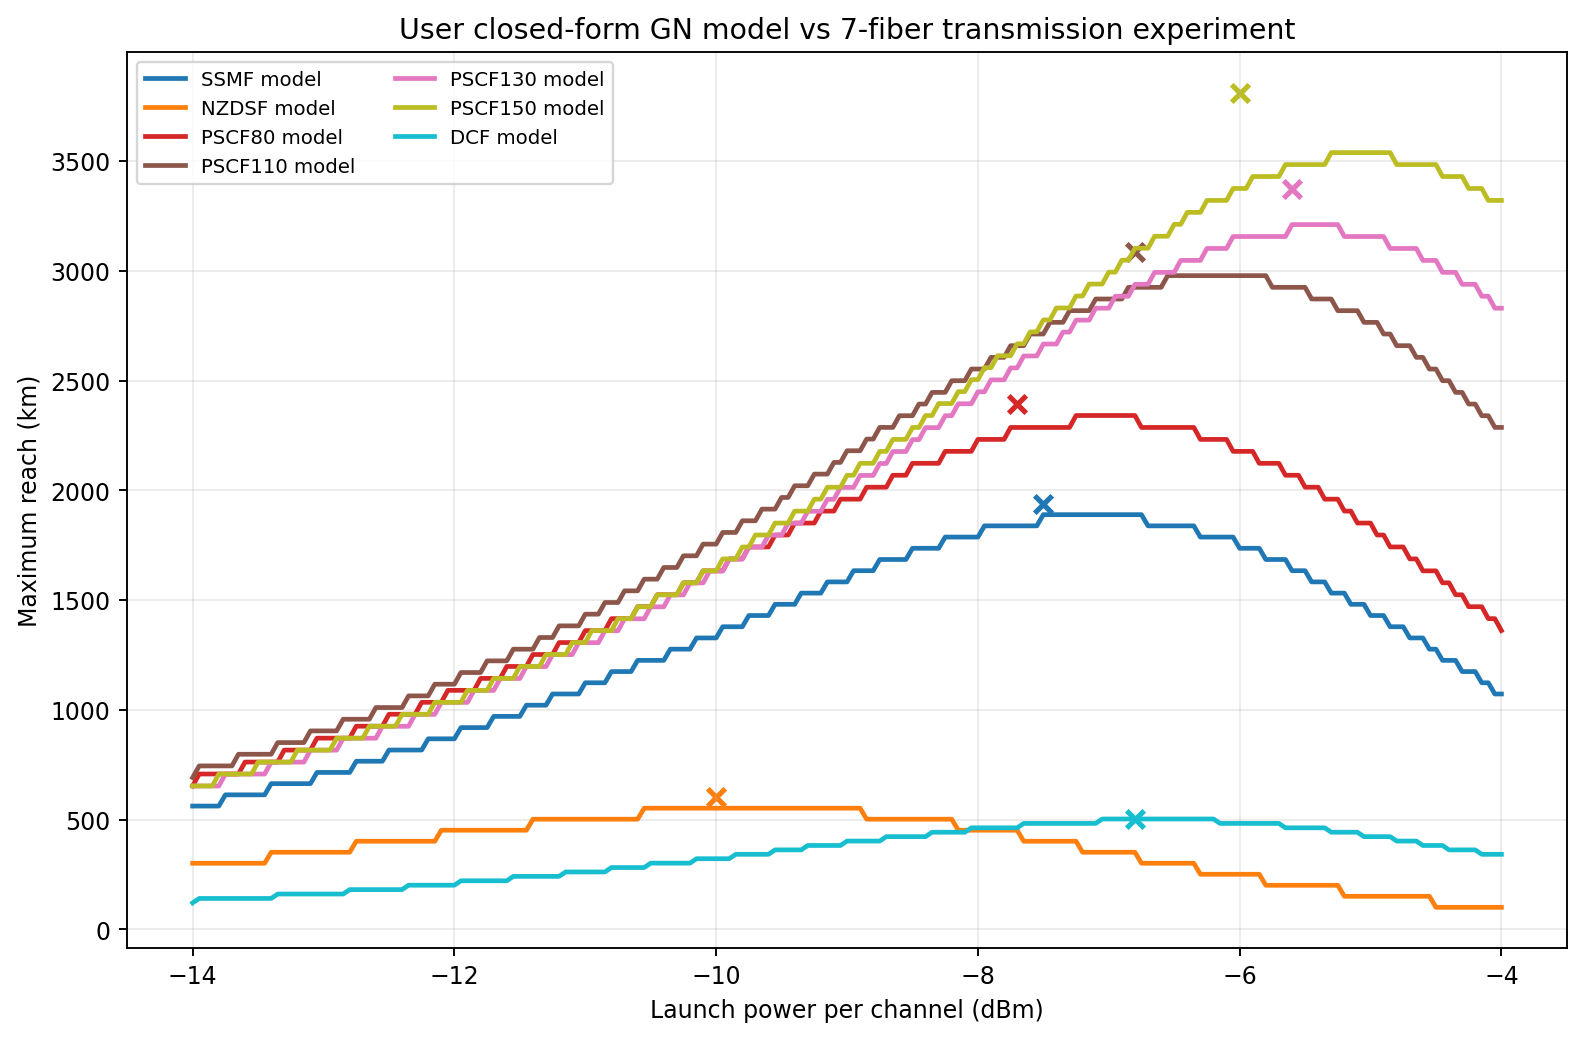

In [2]:

from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

C0 = 299_792_458.0
H = 6.62607015e-34


@dataclass(frozen=True)
class Fiber:
    name: str
    alpha: float
    aeff: float
    gamma: float
    dispersion: float
    span_km: float
    paper_lmax_km: float
    splice_loss_db: float
    paper_popt_dbm: float


FIBERS = [
    Fiber("SSMF", .190, 75, 1.26, 16.84, 51.06, 1940, 0.0, -7.5),
    Fiber("NZDSF", .200, 43, 2.00, 2.58, 50.18, 602, 2.0, -10.0),
    Fiber("PSCF80", .164, 86, 1.04, 16.36, 54.44, 2395, .3, -7.7),
    Fiber("PSCF110", .161, 111, .81, 20.50, 53.18, 3084, .4, -6.8),
    Fiber("PSCF130", .162, 131, .68, 20.92, 54.42, 3374, .6, -5.6),
    Fiber("PSCF150", .161, 150, .59, 20.69, 54.44, 3810, .6, -6.0),
    Fiber("DCF", .457, 16.8, 6.03, -166.47, 20.11, 502, 2.5, -6.8),
]

NCH = 22
RS = 15.625e9
SPACING = 16e9
NF_DB = 5.5
FREQ = C0 / 1557.3e-9
TARGET_EQUIVALENT_SNR_DB = 17.7  # Fig. 4 blue WDM curve at BER=1.5e-2, vector/raster digitized
LAUNCH_DBM = np.linspace(-14, -4, 201)


def beta2_s2_km(D):
    lam = C0/FREQ
    return abs(-(lam**2/(2*np.pi*C0))*(D*1e-6)*1000)


def eta_closed_form(fiber, nspans):
    # Same closed-form structure as the user's Fig. 2 notebook.
    alpha_field = fiber.alpha / 8.685889638
    b2 = beta2_s2_km(fiber.dispersion)
    argument = np.pi**2*b2*RS**2/(4*alpha_field) * NCH**(2*RS/SPACING)
    return nspans*4*fiber.gamma**2/(27*np.pi*b2*alpha_field*RS**2)*np.arcsinh(argument)


def ase_w(fiber, nspans):
    gain = 10**((fiber.alpha*fiber.span_km + fiber.splice_loss_db)/10)
    return nspans*H*FREQ*10**(NF_DB/10)*RS*(gain-1)


def snr_db(fiber, nspans, p_dbm):
    p = 10**((p_dbm-30)/10)
    return 10*np.log10(p/(ase_w(fiber,nspans)+eta_closed_form(fiber,nspans)*p**3))


def reach_curve(fiber):
    reaches=[]
    for p in LAUNCH_DBM:
        feasible=[n for n in range(1,201) if snr_db(fiber,n,p)>=TARGET_EQUIVALENT_SNR_DB]
        reaches.append((max(feasible) if feasible else 0)*fiber.span_km)
    return np.asarray(reaches)


rows=[]; curves={}
for f in FIBERS:
    curve=reach_curve(f); curves[f.name]=curve
    i=int(np.argmax(curve)); model_lmax=float(curve[i]); model_p=float(LAUNCH_DBM[i])
    rows.append([f.name, f.paper_lmax_km, model_lmax, 100*(model_lmax-f.paper_lmax_km)/f.paper_lmax_km,
                 f.paper_popt_dbm, model_p, model_p-f.paper_popt_dbm])

comparison=pd.DataFrame(rows, columns=["Fiber","Experiment Lmax km","Model Lmax km","Reach error %",
                                       "Experiment Popt dBm","Model Popt dBm","Popt error dB"])
reach_rmse=float(np.sqrt(np.mean((comparison["Model Lmax km"]-comparison["Experiment Lmax km"])**2)))
reach_mape=float(np.mean(np.abs(comparison["Reach error %"])))
p_mae=float(np.mean(np.abs(comparison["Popt error dB"])))

print("=== Nespola et al. experimental fixed-capacity benchmark ===")
print("Gross line rate = 22 x 125 Gb/s = 2.75 Tb/s; target BER = 1.5e-2")
print(f"Digitized terminal threshold used for convention alignment: {TARGET_EQUIVALENT_SNR_DB:.1f} dB")
print(comparison.to_string(index=False, float_format=lambda x:f"{x:.3f}"))
print(f"\nReach RMSE={reach_rmse:.1f} km, reach MAPE={reach_mape:.2f}%, optimum-launch-power MAE={p_mae:.2f} dB")

fig, ax=plt.subplots(figsize=(9.2,6.0), constrained_layout=True)
colors=plt.cm.tab10(np.linspace(0,1,len(FIBERS)))
for color,f in zip(colors,FIBERS):
    ax.plot(LAUNCH_DBM,curves[f.name],color=color,lw=2,label=f"{f.name} model")
    ax.scatter(f.paper_popt_dbm,f.paper_lmax_km,color=color,s=55,marker="x",linewidths=2.2)
ax.set_xlabel("Launch power per channel (dBm)"); ax.set_ylabel("Maximum reach (km)")
ax.set_title("User closed-form GN model vs 7-fiber transmission experiment")
ax.grid(True,alpha=.25); ax.legend(ncol=2,fontsize=8.4)
plt.show()

benchmark=pd.DataFrame([
    ["Sohanpal et al. Fig. 2 HCF", "Independent closed-form GN capacity curve", "Throughput vs Pch", 0.1606, "Tb/s RMSE", 0.827, "% MAPE"],
    ["Nespola et al. seven-fiber", "Physical PM-16QAM Nyquist-WDM experiment", "2.75-Tb/s reach vs Pch", reach_rmse, "km RMSE", reach_mape, "% MAPE"],
],columns=["Benchmark","Reference type","Quantity","RMSE","RMSE unit","MAPE","MAPE unit"])
print("\n=== Simulation-paper and experiment-paper cross-validation ===")
print(benchmark.to_string(index=False, float_format=lambda x:f"{x:.3f}"))


## 결론 사용 시 주의

- 시뮬레이션 논문과의 HCF 일치는 동일한 GN 계열 및 공개 파라미터를 사용한 결과입니다.
- 실험 비교에서는 단일 B2B 수신기 threshold를 Fig. 4에서 가져와 모든 7종 파이버에 공통 적용했습니다. 이는 단말기 convention alignment이며 파이버별 curve fitting은 아닙니다.
- 따라서 권장 결론은 ‘closed-form GN 모델이 optimum launch power와 고정 용량 reach를 빠르게 추정하는 데 유효하다’입니다. ‘모든 조건에서 실험을 대체한다’고 일반화하면 안 됩니다. ISRS, Raman amplification, ROADM filtering, modulation-dependent EGN correction, span-to-span variation은 별도 모델이 필요합니다.

## Sources

1. R. Sohanpal *et al.*, arXiv:2606.17942 (2026). https://arxiv.org/abs/2606.17942
2. A. Nespola *et al.*, “GN-Model Validation over Seven Fiber Types in Uncompensated PM-16QAM Nyquist-WDM Links,” *IEEE Photonics Technology Letters* 26(2), 206–209 (2014). Open manuscript: https://backoffice.biblio.ugent.be/download/5743918/5743952
3. A. Carena *et al.*, “Modeling of the Impact of Nonlinear Propagation Effects in Uncompensated Optical Coherent Transmission Links,” *JLT* 30(10), 1524–1539 (2012), DOI: 10.1109/JLT.2012.2189198.
4. P. Poggiolini, “The GN Model of Non-Linear Propagation in Uncompensated Coherent Optical Systems,” *JLT* 30(24), 3857–3879 (2012).